In [3]:
from google.colab import files
uploaded = files.upload()

Saving Train.csv to Train.csv


In [5]:
import pandas as pd

df = pd.read_csv("Train.csv")
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [12]:
df.isnull().sum()

,0
ID,0
Gender,0
Ever_Married,0
Age,0
Graduated,0
Profession,0
Work_Experience,0
Spending_Score,0
Family_Size,0
Var_1,0


In [13]:
df['Ever_Married'].fillna(df['Ever_Married'].mode()[0], inplace=True)
df['Graduated'].fillna(df['Graduated'].mode()[0], inplace=True)
df['Profession'].fillna(df['Profession'].mode()[0], inplace=True)
df['Var_1'].fillna(df['Var_1'].mode()[0], inplace=True)

df['Work_Experience'].fillna(df['Work_Experience'].median(), inplace=True)
df['Family_Size'].fillna(df['Family_Size'].median(), inplace=True)

/tmp/ipykernel_1628/2399608823.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Ever_Married'].fillna(df['Ever_Married'].mode()[0], inplace=True)
/tmp/ipykernel_1628/2399608823.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value,

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = ['Gender','Ever_Married','Graduated','Profession','Spending_Score','Var_1']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [15]:
features = df[['Age','Work_Experience','Family_Size','Spending_Score']]

In [16]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(features)

In [17]:
df['Cluster'].value_counts()

,count
Cluster,
0,2463
2,2447
1,2079
3,1079


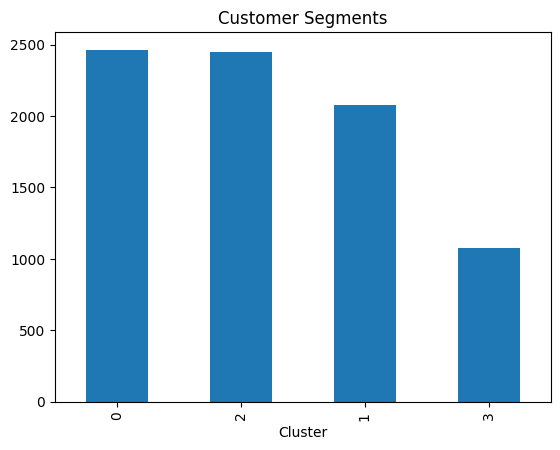

In [18]:
import matplotlib.pyplot as plt

df['Cluster'].value_counts().plot(kind='bar')
plt.title("Customer Segments")
plt.show()

In [19]:
df.groupby('Cluster').mean(numeric_only=True)

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
Cluster,,,,,,,,,,
0,463467.952497,0.511571,0.600487,38.875355,0.746650,1.917580,3.294356,1.280958,2.612667,4.109216
1,463548.098605,0.578644,0.870130,53.302549,0.785955,1.667629,1.789322,0.959115,2.821549,4.251563
2,463473.483858,0.541888,0.191255,25.920311,0.364528,3.650184,2.804250,1.816510,3.467103,3.897017
3,463385.193698,0.582020,0.951807,74.789620,0.631140,4.670992,1.164041,1.277108,2.094532,4.601483
